# SVM

In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
import keras_tuner as kt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import f1_score, roc_auc_score, roc_curve
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

## ECoG Model

### Loading Data

In [66]:
# Load the file
data = torch.load("../Data_Preprocessing/ecog_tensors_channel_indep.pt")

# Extract tensors
X_train = data["X_train"]
y_train = data["y_train"]
X_valid = data["X_valid"]
y_valid = data["y_valid"]
X_test  = data["X_test"]
y_test  = data["y_test"]

# Optional: move to GPU for training
device = "cuda" if torch.cuda.is_available() else "cpu"
X_train = X_train.to(device)
y_train = y_train.to(device)
X_valid = X_valid.to(device)
y_valid = y_valid.to(device)
X_test  = X_test.to(device)
y_test  = y_test.to(device)

print("Training tensor shape:", X_train.shape)

Training tensor shape: torch.Size([21024, 1600, 1])


### Feature Extraction

In [16]:
from scipy.signal import butter, filtfilt, welch
from scipy.stats import skew, kurtosis
from scipy.fft import fft, fftfreq
from pywt import cwt, ContinuousWavelet
from antropy import spectral_entropy, sample_entropy, perm_entropy
from sklearn.preprocessing import MinMaxScaler

# Bandpass filter function
def bandpass_filter(signal, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    filtered_signal = filtfilt(b, a, signal)
    return filtered_signal

# Feature extraction functions
def extract_time_domain_features(signal):
    zcr = np.mean(np.diff(np.signbit(signal)))  # Zero-Crossing Rabte
    features = {
        "Mean": np.mean(signal),
        "Variance": np.var(signal),
        "Energy": np.sum(signal**2),
        "Zero_Crossing_Rate": zcr,
        "RMS": np.sqrt(np.mean(signal**2)),
        "Peak_to_Peak": np.ptp(signal),
        "Skewness": skew(signal),
        "Kurtosis": kurtosis(signal),
    }
    return features

def extract_frequency_domain_features(signal, sampling_frequency):
    # Welch's Power Spectral Density (PSD)
    f, psd = welch(signal, fs=sampling_frequency)
    psd_features = {
        "Delta_Power": np.sum(psd[(f >= 0.5) & (f <= 4)]),
        "Theta_Power": np.sum(psd[(f >= 4) & (f <= 8)]),
        "Alpha_Power": np.sum(psd[(f >= 8) & (f <= 13)]),
        "Beta_Power": np.sum(psd[(f >= 13) & (f <= 30)]),
        "Gamma_Power": np.sum(psd[(f >= 30) & (f <= 50)]),
        "Spectral_Entropy": spectral_entropy(signal, sf=sampling_frequency, method="welch"),
        "Dominant_Frequency": f[np.argmax(psd)],
    }

    # FFT Features
    N = len(signal)
    fft_values = np.abs(fft(signal))[:N // 2]
    fft_freqs = fftfreq(N, d=1 / sampling_frequency)[:N // 2]
    psd_features.update({
        "Dominant_Frequency_FFT": fft_freqs[np.argmax(fft_values)],
        "Total_Power_FFT": np.sum(fft_values**2)
    })
    return psd_features

# Nonlinear features
def higuchi_fractal_dimension(signal, kmax=10):
    L = []
    x = np.array(signal)
    N = len(x)

    for k in range(1, kmax+1):
        Lk = 0
        for m in range(k):
            Lmk = np.sum(np.abs(np.diff(x[m:N:k])))
            Lk += (Lmk * (N - 1) / (k * (N - m)))
        L.append(np.log(Lk / k))

    return -np.polyfit(np.log(range(1, kmax+1)), L, 1)[0]

def lyapunov_exponent(signal):
    N = len(signal)
    epsilon = 0.01  # Small perturbation
    distances = np.abs(np.diff(signal))
    log_distances = np.log(distances[distances > epsilon])
    return np.mean(log_distances) if len(log_distances) > 0 else np.nan

def extract_nonlinear_features(signal):
    ap_entropy = perm_entropy(signal, order=3, delay=1, normalize=True)
    try:
        samp_entropy = sample_entropy(signal, order=2, metric='chebyshev')
    except ValueError:
        samp_entropy = np.nan

    features = {
        "Approximate_Entropy": ap_entropy,
        "Sample_Entropy": samp_entropy,
        "Fractal_Dimension": higuchi_fractal_dimension(signal),
        "Lyapunov_Exponent": lyapunov_exponent(signal)
    }
    return features

def extract_wavelet_features(signal):
    wavelet = ContinuousWavelet("cmor1.5-1.0")
    scales = np.arange(1, 50)
    coefficients, _ = cwt(signal, scales, wavelet)
    coefficients = np.abs(coefficients)

    features = {
        "Wavelet_Coeff_Mean": np.mean(coefficients),
        "Wavelet_Coeff_Std": np.std(coefficients),
        "Wavelet_Coeff_Energy": np.sum(coefficients**2)
    }
    return features

def extract_all_features(signal, fs):
    features = {}

    # Time
    features.update(extract_time_domain_features(signal))

    # Frequency
    features.update(extract_frequency_domain_features(signal, fs))

    # Nonlinear
    features.update(extract_nonlinear_features(signal))

    # Wavelet
    features.update(extract_wavelet_features(signal))

    return features

In [28]:
feature_list = []
feature_names = None

for signal in X_train:
    signal = signal.squeeze()          # remove extra dimension (1600,1) → (1600,)
    signal = signal.cpu().numpy()      # convert tensor → numpy
    
    feats = extract_all_features(signal, fs=1000)

    if feature_names is None:
        feature_names = list(feats.keys())

    feature_list.append([feats[name] for name in feature_names])

X_train_features = np.array(feature_list)

print(X_train_features.shape)

(21024, 24)


In [35]:
X_train_features = np.nan_to_num(X_train_features)

In [29]:
feature_list = []
feature_names = None

for signal in X_valid:
    signal = signal.squeeze()          # remove extra dimension (1600,1) → (1600,)
    signal = signal.cpu().numpy()      # convert tensor → numpy
    
    feats = extract_all_features(signal, fs=1000)

    if feature_names is None:
        feature_names = list(feats.keys())

    feature_list.append([feats[name] for name in feature_names])

X_valid_features = np.array(feature_list)

print(X_valid_features.shape)

(4204, 24)


In [36]:
X_valid_features = np.nan_to_num(X_valid_features)

In [67]:
feature_list = []
feature_names = None

for signal in X_test:
    signal = signal.squeeze()          # remove extra dimension (1600,1) → (1600,)
    signal = signal.cpu().numpy()      # convert tensor → numpy
    
    feats = extract_all_features(signal, fs=1000)

    if feature_names is None:
        feature_names = list(feats.keys())

    feature_list.append([feats[name] for name in feature_names])

X_test_features = np.array(feature_list)

print(X_test_features.shape)

(2804, 24)


In [68]:
X_test_features = np.nan_to_num(X_test_features)

### Training and Hyperparameter Tuning

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

# Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', LinearSVC(max_iter=10000))
])

# Hyperparameter grid
param_grid = {
    'svm__C': [0.001, 0.01, 0.1, 1, 10]
}

In [33]:
y_train = y_train.cpu().numpy()
y_valid = y_valid.cpu().numpy()
y_test  = y_test.cpu().numpy()

In [38]:
# Grid search
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1',   
    n_jobs=-1       
)

# Train
grid.fit(X_train_features, y_train)

print("Best C:", grid.best_params_)
print("Best score:", grid.best_score_)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/uti

Best C: {'svm__C': 10}
Best score: 0.7256768150406371


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [41]:
best_model = grid.best_estimator_

### Evaluation 

In [42]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
# Assuming best_model is your trained SVM
y_pred = best_model.predict(X_test_features)

# For probabilistic metrics (AUC, AUPRC), you need decision function
if hasattr(best_model, "decision_function"):
    y_scores = best_model.decision_function(X_test_features)
else:
    y_scores = best_model.predict_proba(X_test_features)[:, 1]  # only positive class

#### Accuracy, Precision, Recall (Specificity), F1-score, AUROC, AUPRC

In [71]:
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
auc_roc   = roc_auc_score(y_test, y_scores)
auprc     = average_precision_score(y_test, y_scores)
cm        = confusion_matrix(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"AUC-ROC  : {auc_roc:.4f}")
print(f"AUPRC    : {auprc:.4f}")
print("Confusion Matrix:\n", cm)

Accuracy : 0.7989
Precision: 0.8656
Recall   : 0.6375
F1-score : 0.7342
AUC-ROC  : 0.8685
AUPRC    : 0.8400
Confusion Matrix:
 [[1461  121]
 [ 443  779]]


#### Confusion Matrix

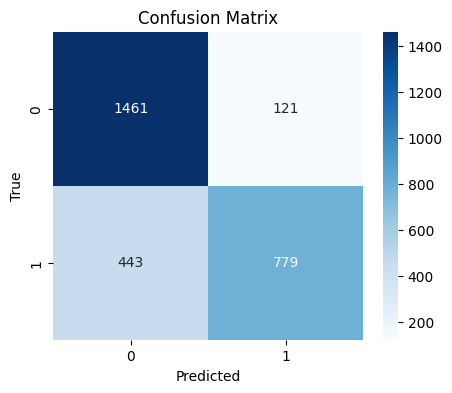

In [72]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

#### ROC and Precision–recall Curves (&maybe learning curve)

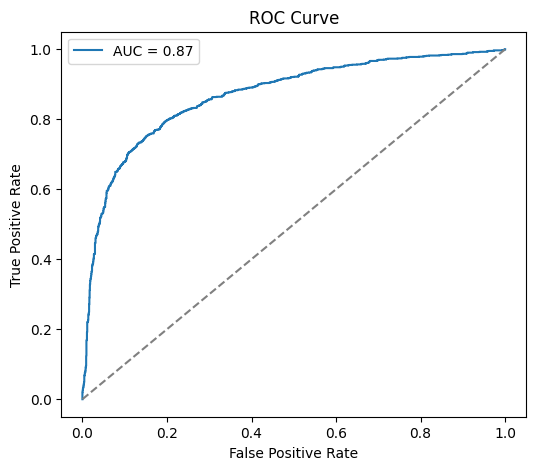

In [74]:
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_roc:.2f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

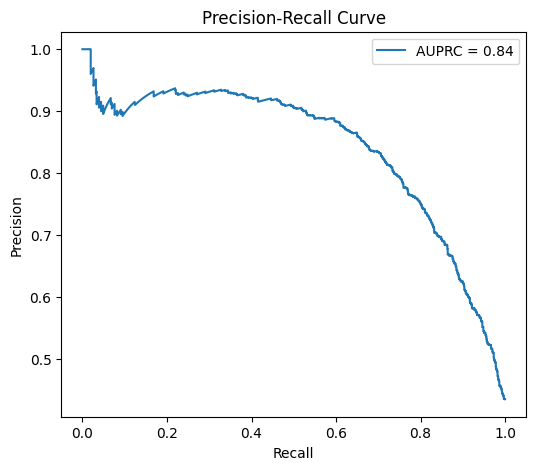

In [75]:
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, y_scores)

plt.figure(figsize=(6,5))
plt.plot(recall_vals, precision_vals, label=f"AUPRC = {auprc:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

## Live Demonstration

In [88]:
seizure_idx = np.where(y_test == 1)[0]
nonseizure_idx = np.where(y_test == 0)[0]

# Random pick
i_seizure = np.random.choice(seizure_idx)
i_nonseizure = np.random.choice(nonseizure_idx)

x_seizure = X_test_features[i_seizure]
x_nonseizure = X_test_features[i_nonseizure]

In [92]:
def prepare_sample(x):
    x = to_patchtst_layout(x[np.newaxis, ...])  # add batch dim
    return torch.tensor(x, dtype=torch.float32).to(device)

In [102]:
def predict_sample(x):
    x = x.reshape(1, -1)  # shape (1, 24)

    pred_class = best_model.predict(x)[0]

    if hasattr(best_model, "predict_proba"):
        prob = best_model.predict_proba(x)[0][1]  # P(seizure)
    else:
        prob = None

    return pred_class, prob

In [108]:
import matplotlib.pyplot as plt

def plot_sample(x, title, pred_class, pred_prob):
    plt.figure(figsize=(10, 4))
    
    plt.plot(x)
    plt.title(
        f"{title}\nPred: {pred_class}" +
        (f" | P(seizure)={pred_prob:.3f}" if pred_prob is not None else "")
    )
    plt.xlabel("Feature index (0–23)")
    plt.ylabel("Feature value")
    plt.grid(True)
    plt.show()

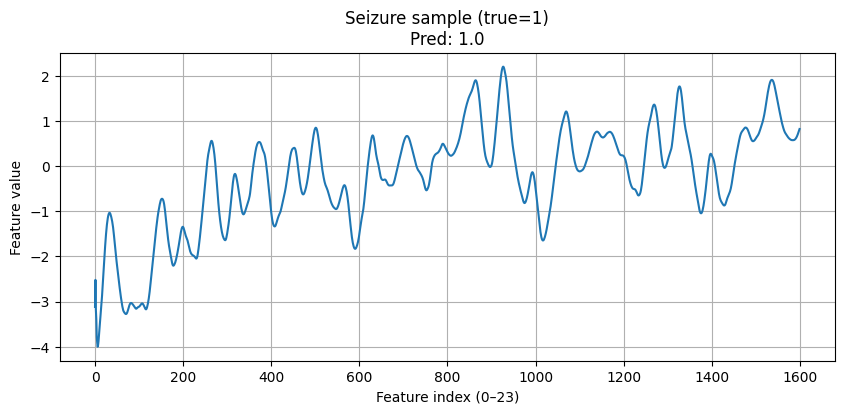

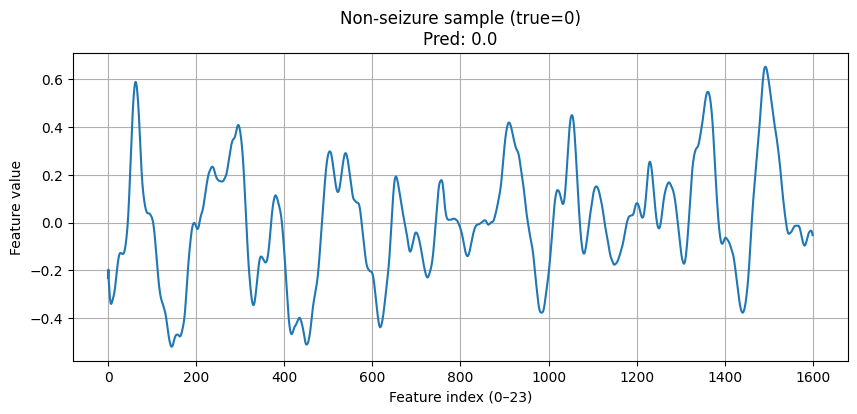

In [109]:
# Predict
pred_s, prob_s = predict_sample(x_seizure)
pred_ns, prob_ns = predict_sample(x_nonseizure)

# Plot
plot_sample(X_test[i_seizure], "Seizure sample (true=1)", pred_s, prob_s)
plot_sample(X_test[i_nonseizure], "Non-seizure sample (true=0)", pred_ns, prob_ns)